In [1]:
using Distributions,Random, Optim, Printf, LinearAlgebrausing Plots
include("VesicleShapesJulia.jl")

ArgumentError: ArgumentError: Package Distributions not found in current path.
- Run `import Pkg; Pkg.add("Distributions")` to install the Distributions package.

In [3]:
a=3

3

In [4]:
import Pkg;
Pkg.add("Plots")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed libfdk_aac_jll ──────────── v2.0.3+0
   Installed LERC_jll ────────────────── v4.0.1+0
   Installed GR_jll ──────────────────── v0.73.13+0
   Installed Libmount_jll ────────────── v2.40.3+0
   Installed Opus_jll ────────────────── v1.3.3+0
   Installed JpegTurbo_jll ───────────── v3.1.1+0
   Installed LoggingExtras ───────────── v1.1.0
   Installed Unitful ─────────────────── v1.22.0
   Installed ConcurrentUtilities ─────── v2.5.0
   Installed Xorg_xkbcomp_jll ────────── v1.4.6+1
   Installed Xorg_libpthread_stubs_jll ─ v0.1.2+0
   Installed PlotUtils ───────────────── v1.4.3
   Installed Cairo_jll ───────────────── v1.18.2+1
   Installed HTTP ────────────────────── v1.10.15
   Installed ColorSchemes ────────────── v3.29.0
   Installed Fontconfig_jll ──────────── v2.15.0+0
   Installed Statistics ──────────────── v1.11.1
   Installed Libgpg_error_jll ────────── v1.51.1+0
   Install

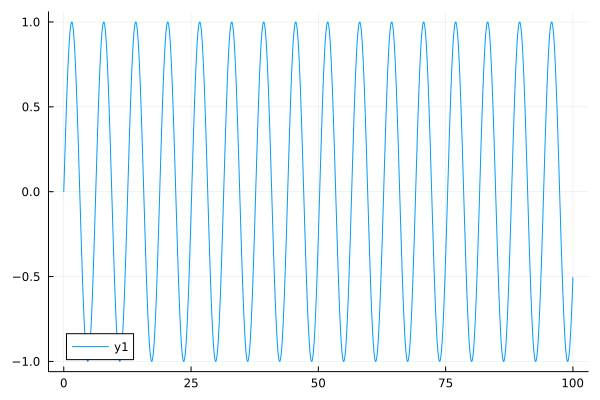

In [15]:
using Plots
x = range(0, 100, length=1000)
y = sin.(x)
plot(x, y)

In [23]:
Random.seed!(123) # Setting the seed
N = 50
params = zeros(N, 3)
init_params = zeros(N, 3)

cost = zeros(N, 3)
eps = zeros(N, 3)
eps_optimal = zeros(N, 3)


Rvesicle = 30.0
Rparticle = 4.0
rpa = Rparticle/Rvesicle
phi_deg = 60.0
phi = deg2rad(phi_deg)

omega = 3.0
sigma = 0.019
u0 = 1.0

omega_list = range(2.6, stop=π, length=N)

for (i, omega) in enumerate(omega_list)
    init_params[i,:] = [omega,sigma,u0]

    # Boundary conditions
    psistar = π + phi
    ustar = 1 / rpa
    xstar = rpa * sin(phi)

    # Check on xstar value
    if xstar < 0.035
        @printf "xstar: %.5f\n" xstar
        error("xstar too small, can lead to divergences")
    end

    boundary_conditions = [psistar, ustar, xstar]
    free_params_extended = [omega, sigma, u0]
    # @printf "free_params_extended: %.5f, %.5f, %.5f\n" omega sigma u0

    # Shooting algorithm and solver
    result = optimize(x -> sum(abs2, Residuales(x, boundary_conditions)), free_params_extended, NelderMead())


    

    @printf "Err: %.5f\n" result.minimum

    best_parameters = result.minimizer
    # print(best_parameters)
    # sol = Onesolution(best_parameters)
    # p = PlotShapes(sol, best_parameters, rpa, phi_deg)
    # display(p)

    # Store the results
    params[i, :] = result.minimizer
    cost[i, 1] = result.f_calls
    cost[i, 2] = result.minimum

    # eps_omega_opt = abs(omega0 - result.minimizer[1])
    # eps_sigma_opt = abs(sigma0 - result.minimizer[2])
    # eps_u0_opt = abs(u00 - result.minimizer[3])
    # eps_optimal[i, :] = [eps_omega_opt, eps_sigma_opt, eps_u0_opt]
end

# # Save results to files
# using NPZ
# npzwrite("eps_optimal.npy", eps_optimal)
# npzwrite("eps.npy", eps)
# npzwrite("params.npy", params)

integration failed
integration failed


┌ Warning: At t=0.4846461356036338, dt was forced below floating point epsilon 5.551115123125783e-17, and step error estimate = 1.8051551305654555e59. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase /home/pietro/.julia/packages/SciMLBase/vhP5T/src/integrator_interface.jl:600
┌ Warning: At t=0.6676888277045012, dt was forced below floating point epsilon 1.1102230246251565e-16, and step error estimate = 655132.5428684282. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase /home/pietro/.julia/packages/SciMLBase/vhP5T/src/integrator_interface.jl:600


integration failed


┌ Warning: At t=0.7072616267737568, dt was forced below floating point epsilon 1.1102230246251565e-16, and step error estimate = 1.9556432832748931e59. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase /home/pietro/.julia/packages/SciMLBase/vhP5T/src/integrator_interface.jl:600


Err: 0.00073
integration failed
integration failed
integration failed
integration failed


...

┌ Warning: At t=0.4586356796421768, dt was forced below floating point epsilon 5.551115123125783e-17, and step error estimate = 783322.4094889585. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase /home/pietro/.julia/packages/SciMLBase/vhP5T/src/integrator_interface.jl:600
┌ Warning: At t=0.6766765755962749, dt was forced below floating point epsilon 1.1102230246251565e-16, and step error estimate = 664312.7688723007. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase /home/pietro/.julia/packages/SciMLBase/vhP5T/src/integrator_interface.jl:600
┌ Warning: At t=0.7361148710708695, dt was forced below floating point epsilon 1.1102230246251565e-16, and step error estimate = 668404.1079349845. Aborting. There is either an erro

Err: 0.00042
integration failed
integration failed
integration failed
integration failed


┌ Warning: At t=0.45578690074744876, dt was forced below floating point epsilon 5.551115123125783e-17, and step error estimate = 786467.1915507029. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase /home/pietro/.julia/packages/SciMLBase/vhP5T/src/integrator_interface.jl:600
┌ Warning: At t=0.5925658070002349, dt was forced below floating point epsilon 1.1102230246251565e-16, and step error estimate = 934292.9837351893. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase /home/pietro/.julia/packages/SciMLBase/vhP5T/src/integrator_interface.jl:600
┌ Warning: At t=0.6427918988489777, dt was forced below floating point epsilon 1.1102230246251565e-16, and step error estimate = 794123.938010313. Aborting. There is either an erro

Err: 0.00064
integration failed


┌ Warning: At t=0.45502397344411183, dt was forced below floating point epsilon 5.551115123125783e-17, and step error estimate = 1.8070527989697556e59. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase /home/pietro/.julia/packages/SciMLBase/vhP5T/src/integrator_interface.jl:600


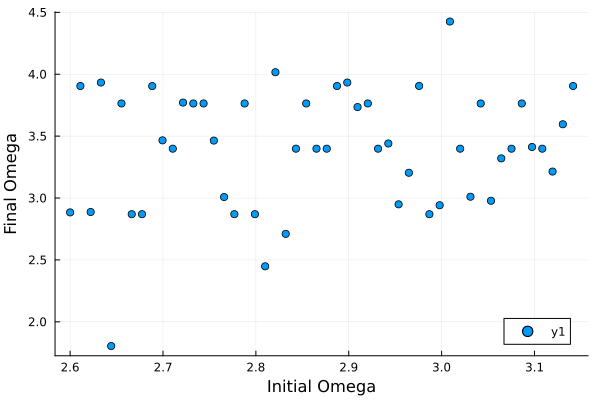

In [24]:
plot(init_params[:, 1], params[:, 1], seriestype = :scatter)
xlabel!("Initial Omega")
ylabel!("Final Omega")


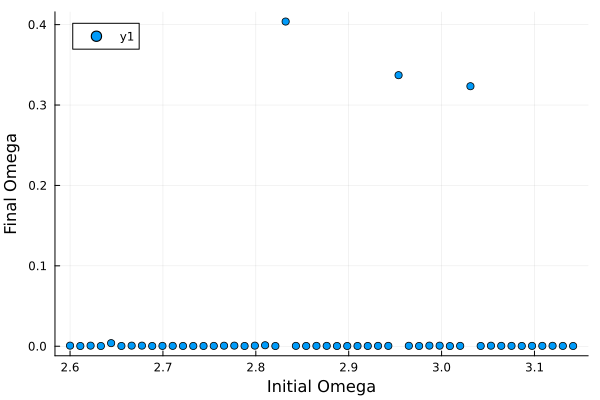

In [26]:
plot(init_params[:, 1],cost[:, 2], seriestype = :scatter)
xlabel!("Initial Omega")
ylabel!("cost")

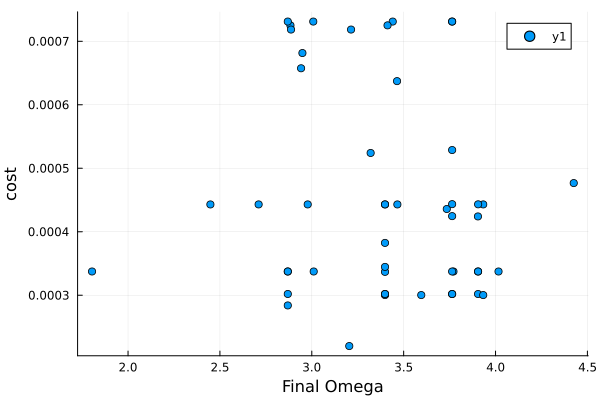

In [35]:
mask = cost[:, 2].<0.001
plot(params[:, 1],cost[mask, 2], seriestype = :scatter)
xlabel!("Final Omega")
ylabel!("cost")


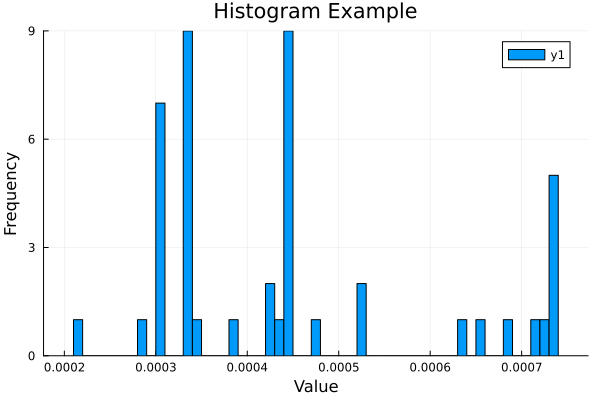

In [36]:
histogram(cost[mask, 2], bins=50, xlabel="Value", ylabel="Frequency", title="Histogram Example")